In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping

fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print(f'X_train_full shape: {X_train_full.shape}')
print(f'X_test shape: {X_test.shape}')

X_train, X_valid = X_train_full[5000:] / 255.0, X_train_full[:5000] / 255.0

y_train, y_valid = y_train_full[5000:], y_train_full[:5000]
X_test = X_test / 255.0

print(f'X_train shape: {X_train.shape}')
print(f'X_valid shape: {X_valid.shape}')




X_train_full shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
X_train shape: (55000, 28, 28)
X_valid shape: (5000, 28, 28)


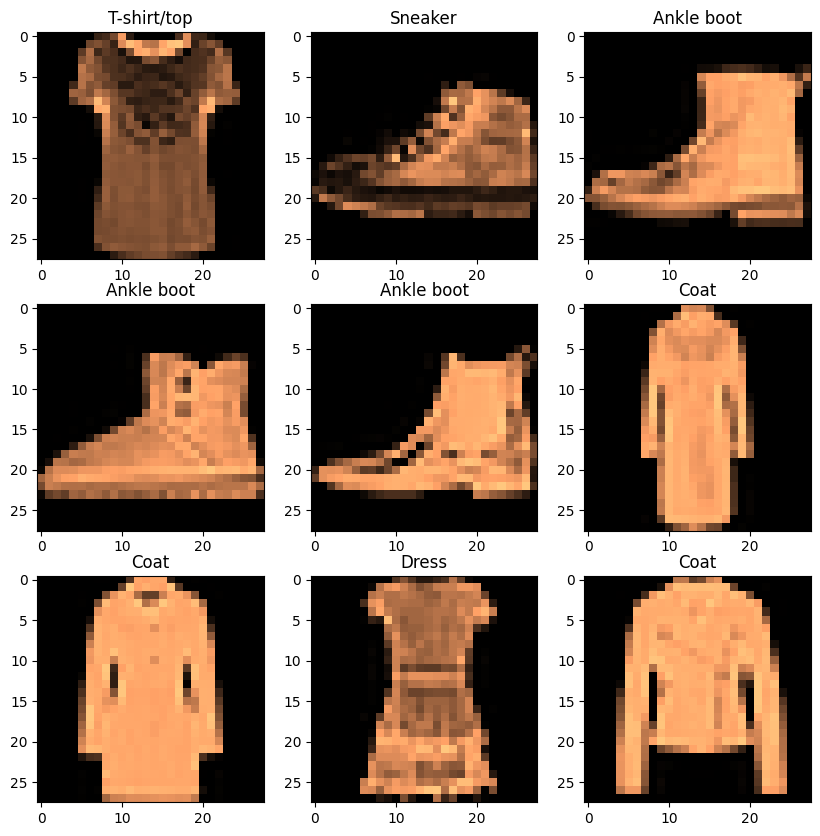

In [8]:
#Visualiztion of the data
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(1,10,1):
    plt.subplot(3,3,i)
    plt.imshow(X_train[i], cmap=plt.cm.copper)
    plt.title(class_names[y_train[i]])
    
plt.show()

In [9]:
#Specifying the model we are going to use
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Flatten())
model.add(Dense(300, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#history = model.fit(X_train, y_train, epochs=60, validation_data=(X_valid, y_valid), callbacks=[early_stopping], verbose=2)

history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), verbose=2)
 



Epoch 1/20
1719/1719 - 14s - 8ms/step - accuracy: 0.8758 - loss: 0.3500 - val_accuracy: 0.8816 - val_loss: 0.3553
Epoch 2/20
1719/1719 - 12s - 7ms/step - accuracy: 0.8819 - loss: 0.3376 - val_accuracy: 0.8874 - val_loss: 0.3574
Epoch 3/20
1719/1719 - 20s - 12ms/step - accuracy: 0.8843 - loss: 0.3296 - val_accuracy: 0.8762 - val_loss: 0.3903
Epoch 4/20
1719/1719 - 11s - 7ms/step - accuracy: 0.8871 - loss: 0.3245 - val_accuracy: 0.8586 - val_loss: 0.4502
Epoch 5/20
1719/1719 - 21s - 12ms/step - accuracy: 0.8917 - loss: 0.3176 - val_accuracy: 0.8888 - val_loss: 0.3850
Epoch 6/20
1719/1719 - 20s - 12ms/step - accuracy: 0.8933 - loss: 0.3123 - val_accuracy: 0.8742 - val_loss: 0.4991
Epoch 7/20
1719/1719 - 20s - 12ms/step - accuracy: 0.8952 - loss: 0.3096 - val_accuracy: 0.8822 - val_loss: 0.3987
Epoch 8/20
1719/1719 - 11s - 6ms/step - accuracy: 0.8972 - loss: 0.3023 - val_accuracy: 0.8904 - val_loss: 0.4192
Epoch 9/20
1719/1719 - 12s - 7ms/step - accuracy: 0.8984 - loss: 0.2985 - val_accura

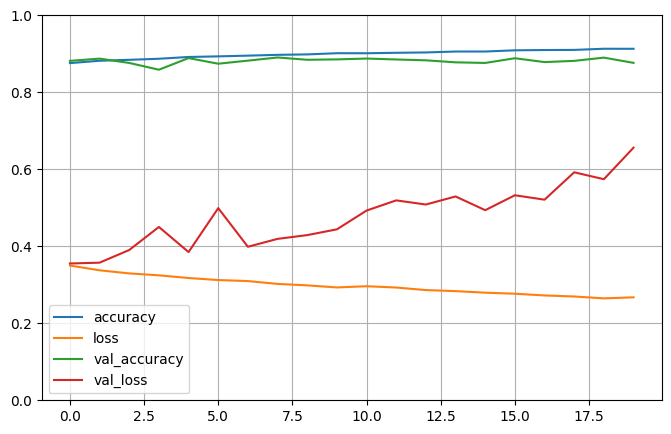

In [13]:
#Visualization of history
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [14]:
model.evaluate(X_test, y_test, verbose=2)

313/313 - 2s - 5ms/step - accuracy: 0.8643 - loss: 0.6630


[0.6630260944366455, 0.864300012588501]

In [20]:
X_new = X_test[:3]

print(X_new)

y_proba = model.predict(X_new, verbose=1)
y_proba.round(2)

print(y_proba)

classes_x = np.argmax(y_proba, axis=1)
print(f'Predicted classes: {class_names[classes_x[0]]} {class_names[classes_x[1]]} {class_names[classes_x[2]]}')
y_new = y_test[:3]
print(f'Actual classes: {class_names[y_new[0]]} {class_names[y_new[1]]} {class_names[y_new[2]]}')




[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
[[8.6091337e-22 6.5393111e-18 3.0157013e-28 4.3140603e-21 2.7696642e-21
  1.0876214e-07 1.8516445e-27 1.2355563e-05 3.0235259e-18 9.9998748e-01]
 [2.7540970e-09 4.9217840e-32 9.9909830e-01 3.8638022e-16 8.8553230e-04
  1.0558279e-34 1.6197266e-05 0.0000000e+00 2.3859084e-18 0.0000000e+00]
 [0.0000000e+00 1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]]
Predicted classes: Ankle boot Pul

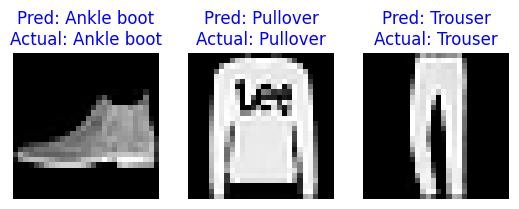

In [24]:
#X_images = X_test.reshape(-1, 28, 28)

for i in range(3):
    correct = classes_x[i] == y_new[i]
    color = 'blue' if correct else 'red'

    plt.subplot(1, 3, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.axis('off')
    
    plt.title(
        f"Pred: {class_names[classes_x[i]]}\n"
        f"Actual: {class_names[y_new[i]]}",
        color=color
    )
